# Master Environment Testing and Training Notebook

This notebook demonstrates:
1. **Testing the CIO Allocator Environment** - Validate the master environment that allocates capital across specialist strategies
2. **Training the Master Agent** - Train a PPO agent to optimize capital allocation
3. **Evaluating Performance** - Analyze the learned allocation policy and portfolio performance

The master environment receives strategy performance signals from the 7 specialist trading strategies and decides how to allocate capital to maximize risk-adjusted returns.

In [36]:
# Import required libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Import environment
from environments.master_env.env_cio_allocator import CIOAllocatorEnv

# Set random seeds for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Libraries imported successfully")
print(f"✓ Working directory: {Path.cwd()}")

✓ Libraries imported successfully
✓ Working directory: c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\notebooks


## 1. Generate Synthetic Specialist Performance Data

Since we don't have trained specialist agents yet, we'll simulate their performance with realistic characteristics:
- Different Sharpe ratios (0.5 to 2.0)
- Varying volatilities
- Different correlation structures
- Regime-dependent performance

In [37]:
def generate_specialist_performance(n_steps=500, n_strategies=7):
    """
    Generate synthetic performance data for specialist strategies.
    
    Returns:
        DataFrame with columns for each strategy's returns and metrics
    """
    
    # Strategy characteristics - using exact names from CIOAllocatorEnv.STRATEGIES
    strategies = {
        'statistical_arbitrage': {'sharpe': 1.5, 'vol': 0.10, 'regime_sensitivity': 0.3},
        'market_making': {'sharpe': 1.2, 'vol': 0.08, 'regime_sensitivity': 0.5},
        'volatility_trading': {'sharpe': 0.8, 'vol': 0.15, 'regime_sensitivity': 0.7},
        'delta_hedging': {'sharpe': 0.6, 'vol': 0.12, 'regime_sensitivity': 0.4},
        'futures_spreads': {'sharpe': 1.0, 'vol': 0.11, 'regime_sensitivity': 0.3},
        'factor_tracking': {'sharpe': 1.8, 'vol': 0.09, 'regime_sensitivity': 0.2},
        'fx_arbitrage': {'sharpe': 1.3, 'vol': 0.13, 'regime_sensitivity': 0.6}
    }
    
    # Generate market regime (0=normal, 1=volatile)
    regime = np.random.choice([0, 1], size=n_steps, p=[0.7, 0.3])
    
    data = {}
    
    for strat_name, params in strategies.items():
        # Base returns
        base_return = params['sharpe'] * params['vol'] / np.sqrt(252)
        
        # Regime adjustment
        regime_impact = params['regime_sensitivity'] * regime * params['vol']
        
        # Generate returns with autocorrelation
        returns = np.zeros(n_steps)
        returns[0] = np.random.normal(base_return, params['vol'] / np.sqrt(252))
        
        for t in range(1, n_steps):
            # AR(1) process for persistence
            returns[t] = (0.1 * returns[t-1] + 
                         np.random.normal(base_return, params['vol'] / np.sqrt(252)) -
                         regime_impact[t] / np.sqrt(252))
        
        # Calculate cumulative returns and metrics
        data[f'{strat_name}_return'] = returns
        data[f'{strat_name}_cumret'] = np.exp(np.cumsum(returns)) - 1
        
        # Rolling Sharpe (20-day)
        if n_steps >= 20:
            rolling_sharpe = pd.Series(returns).rolling(20).apply(
                lambda x: np.sqrt(252) * x.mean() / (x.std() + 1e-8)
            ).fillna(0).values
        else:
            rolling_sharpe = np.zeros(n_steps)
        data[f'{strat_name}_sharpe'] = rolling_sharpe
        
        # Volatility (20-day rolling)
        if n_steps >= 20:
            rolling_vol = pd.Series(returns).rolling(20).std().fillna(params['vol']).values * np.sqrt(252)
        else:
            rolling_vol = np.ones(n_steps) * params['vol']
        data[f'{strat_name}_vol'] = rolling_vol
    
    # Add market regime
    data['regime'] = regime
    data['vix'] = 15 + 20 * regime + np.random.normal(0, 3, n_steps)
    
    df = pd.DataFrame(data)
    df.index.name = 'timestep'
    
    return df

# Generate data
print("Generating synthetic specialist performance data...")
specialist_data = generate_specialist_performance(n_steps=500)

print(f"✓ Generated {len(specialist_data)} timesteps of data")
print(f"✓ Columns: {specialist_data.shape[1]}")
print(f"\nFirst few rows:")
print(specialist_data.head())

Generating synthetic specialist performance data...
✓ Generated 500 timesteps of data
✓ Columns: 30

First few rows:
          statistical_arbitrage_return  statistical_arbitrage_cumret  \
timestep                                                               
0                             0.011602                      0.011670   
1                             0.020538                      0.032662   
2                             0.015600                      0.048898   
3                             0.007375                      0.056663   
4                             0.004527                      0.061457   

          statistical_arbitrage_sharpe  statistical_arbitrage_vol  \
timestep                                                            
0                                  0.0                   1.587451   
1                                  0.0                   1.587451   
2                                  0.0                   1.587451   
3                                

## 2. Visualize Specialist Strategy Performance

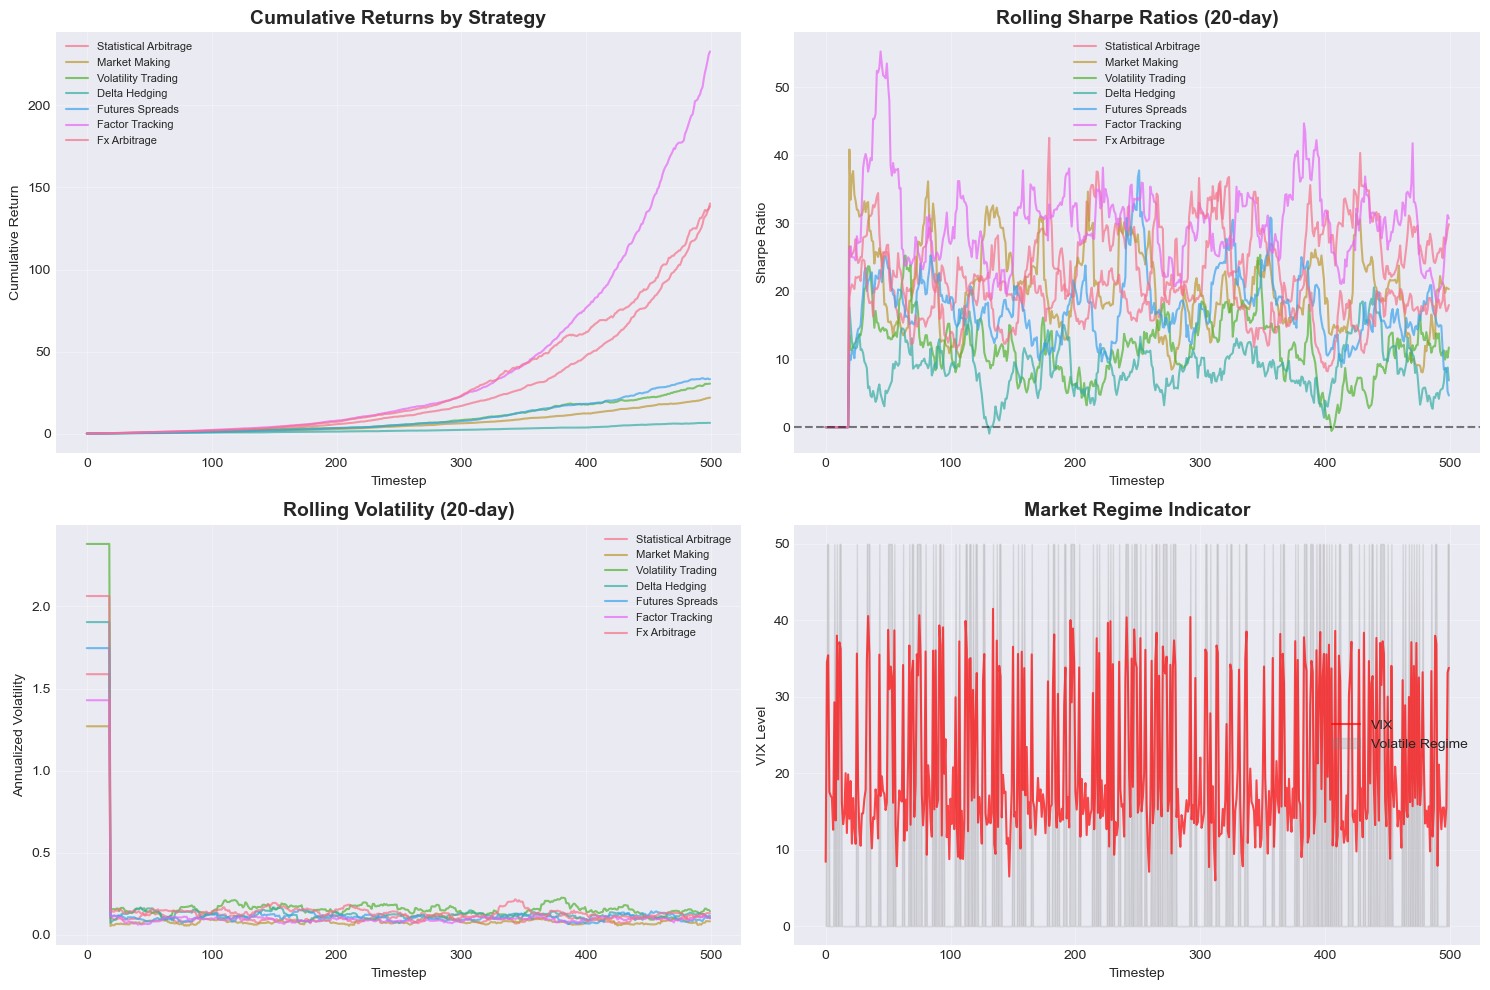


STRATEGY PERFORMANCE SUMMARY
Statistical Arbitrage | Return: 14024.86% | Sharpe: 25.24 | Vol: 9.99%
Market Making        | Return: 2190.73% | Sharpe: 20.56 | Vol: 7.87%
Volatility Trading   | Return: 3042.38% | Sharpe: 11.59 | Vol: 15.34%
Delta Hedging        | Return: 651.96% | Sharpe:  8.82 | Vol: 11.85%
Futures Spreads      | Return: 3317.84% | Sharpe: 17.70 | Vol: 10.55%
Factor Tracking      | Return: 23294.03% | Sharpe: 30.19 | Vol: 9.23%
Fx Arbitrage         | Return: 13852.71% | Sharpe: 19.09 | Vol: 13.40%


In [38]:
# Plot cumulative returns
strategies = ['statistical_arbitrage', 'market_making', 'volatility_trading', 'delta_hedging', 
              'futures_spreads', 'factor_tracking', 'fx_arbitrage']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cumulative returns
ax = axes[0, 0]
for strat in strategies:
    ax.plot(specialist_data[f'{strat}_cumret'], label=strat.replace('_', ' ').title(), alpha=0.7)
ax.set_title('Cumulative Returns by Strategy', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# Rolling Sharpe ratios
ax = axes[0, 1]
for strat in strategies:
    ax.plot(specialist_data[f'{strat}_sharpe'], label=strat.replace('_', ' ').title(), alpha=0.7)
ax.set_title('Rolling Sharpe Ratios (20-day)', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# Volatility
ax = axes[1, 0]
for strat in strategies:
    ax.plot(specialist_data[f'{strat}_vol'], label=strat.replace('_', ' ').title(), alpha=0.7)
ax.set_title('Rolling Volatility (20-day)', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Annualized Volatility')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# Market regime
ax = axes[1, 1]
ax.plot(specialist_data['vix'], color='red', alpha=0.7, label='VIX')
ax.fill_between(range(len(specialist_data)), 0, specialist_data['regime'] * 50, 
                alpha=0.2, color='gray', label='Volatile Regime')
ax.set_title('Market Regime Indicator', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('VIX Level')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("STRATEGY PERFORMANCE SUMMARY")
print("="*70)
for strat in strategies:
    final_return = specialist_data[f'{strat}_cumret'].iloc[-1]
    avg_sharpe = specialist_data[f'{strat}_sharpe'].iloc[20:].mean()
    avg_vol = specialist_data[f'{strat}_vol'].iloc[20:].mean()
    print(f"{strat.replace('_', ' ').title():20s} | Return: {final_return:6.2%} | Sharpe: {avg_sharpe:5.2f} | Vol: {avg_vol:5.2%}")
print("="*70)

## 3. Test CIO Allocator Environment

Create and test the master environment that will learn to allocate capital across strategies.

In [39]:
# Create market data (VIX and regime indicator already in specialist_data)
# For the environment, we'll use the specialist_data as market_data
market_data = specialist_data[['regime', 'vix']].copy()

# Create the CIO Allocator environment
env = CIOAllocatorEnv(
    specialist_data=specialist_data,
    market_data=market_data,
    initial_capital=10_000_000,  # $10M total capital
    lookback_window=20,
    rebalance_frequency=5,  # Rebalance every 5 days
    transaction_cost=0.001,  # 10 bps
    max_single_allocation=0.30,  # Max 30% per strategy
    min_single_allocation=0.05,   # Min 5% per strategy
    risk_free_rate=0.02
)

print("✓ CIO Allocator Environment Created")
print(f"  Action space: {env.action_space}")
print(f"  Observation space: {env.observation_space}")
print(f"  Initial capital: ${env.initial_capital:,.0f}")
print(f"  Number of strategies: {len(env.STRATEGIES)}")

# Test reset
obs, info = env.reset()
print("\n✓ Environment reset successful")
print(f"  Observation shape: {obs.shape}")
print(f"  Initial portfolio value: ${info['portfolio_value']:,.2f}")
print(f"\n  Info keys: {list(info.keys())}")

✓ CIO Allocator Environment Created
  Action space: Box(0.0, 1.0, (7,), float32)
  Observation space: Box(-inf, inf, (130,), float32)
  Initial capital: $10,000,000
  Number of strategies: 7

✓ Environment reset successful
  Observation shape: (130,)
  Initial portfolio value: $10,000,000.00

  Info keys: ['portfolio_value', 'initial_weights']


In [40]:
# Test random actions
print("Testing environment with random actions...\n")

obs, info = env.reset()
episode_rewards = []
portfolio_values = [info['portfolio_value']]
allocations_history = []

for step in range(50):
    # Random action (allocate to each strategy)
    action = env.action_space.sample()
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    episode_rewards.append(reward)
    portfolio_values.append(info['portfolio_value'])
    allocations_history.append(info['weights'].copy())  # Changed from 'allocations' to 'weights'
    
    if step < 5:
        print(f"Step {step+1}:")
        print(f"  Action (raw): {action}")
        print(f"  Weights (normalized): {info['weights']}")
        print(f"  Reward: {reward:.4f}")
        print(f"  Portfolio value: ${info['portfolio_value']:,.2f}")
        print(f"  Sharpe ratio: {info.get('sharpe_ratio', 0):.3f}")
        print()
    
    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break

print(f"✓ Test complete!")
print(f"  Total steps: {len(episode_rewards)}")
print(f"  Total reward: {sum(episode_rewards):.2f}")
print(f"  Final portfolio: ${portfolio_values[-1]:,.2f}")
print(f"  Return: {(portfolio_values[-1] / portfolio_values[0] - 1) * 100:.2f}%")

Testing environment with random actions...

Step 1:
  Action (raw): [0.62087536 0.9056557  0.02245286 0.37415773 0.65210336 0.18300375
 0.8343348 ]
  Weights (normalized): [0.16557737 0.24152364 0.04790418 0.09978178 0.17390536 0.04880412
 0.22250353]
  Reward: -0.1429
  Portfolio value: $10,031,075.32
  Sharpe ratio: 0.000

Step 2:
  Action (raw): [0.50659555 0.1407199  0.07934157 0.8978625  0.7435263  0.91384053
 0.9662854 ]
  Weights (normalized): [0.11376686 0.04770089 0.04770089 0.20163421 0.16697472 0.20522243
 0.21700005]
  Reward: -1.4148
  Portfolio value: $10,135,268.09
  Sharpe ratio: 0.000

Step 3:
  Action (raw): [0.01599465 0.51383334 0.4441234  0.4489664  0.07237345 0.8792168
 0.5992559 ]
  Weights (normalized): [0.04671657 0.16144207 0.13953978 0.14106143 0.04671657 0.27624243
 0.18828112]
  Reward: -1.4216
  Portfolio value: $10,239,944.38
  Sharpe ratio: 0.000

Step 4:
  Action (raw): [0.13415886 0.40261286 0.0365673  0.3865859  0.67951983 0.6923947
 0.87078446]
  Wei

## 4. Train PPO Agent for Capital Allocation

Now we'll train a PPO agent to learn the optimal capital allocation policy.

In [41]:
# Import PPO agent
from agents.ppo import PPOAgent

# Create PPO agent
agent = PPOAgent(
    env=env,
    hidden_dims=(256, 256),
    learning_rate=3e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    value_coef=0.5,
    entropy_coef=0.01,
    max_grad_norm=0.5,
    n_steps=2048,
    batch_size=64,
    n_epochs=10
)

print("✓ PPO Agent created")
print(f"  State dimension: {env.observation_space.shape[0]}")
print(f"  Action dimension: {env.action_space.shape[0]}")
print(f"  Learning rate: {3e-4}")
print(f"  Hidden dimensions: (256, 256)")

✓ PPO Agent created
  State dimension: 130
  Action dimension: 7
  Learning rate: 0.0003
  Hidden dimensions: (256, 256)


In [42]:
# Train the agent using built-in train method
print("Starting PPO training...\n")
print("="*80)

# Calculate total timesteps (100 episodes × 200 max steps ≈ 20,000 timesteps)
total_timesteps = 20000

# Train the agent
agent.train(total_timesteps=total_timesteps, log_interval=10)

print("="*80)
print("\n✓ Training complete!")

# Extract training metrics from agent
training_rewards = agent.training_metrics['episode_rewards']
print(f"  Total episodes: {len(training_rewards)}")
print(f"  Mean reward: {np.mean(training_rewards):.2f}")
print(f"  Final avg reward (last 10): {np.mean(training_rewards[-10:]):.2f}")

Starting PPO training...

Training PPO agent for 20000 timesteps...
Device: cpu


Episode 10, Timestep 920, Avg Reward: 149.06
Episode 20, Timestep 1840, Avg Reward: 145.56
Episode 20, Timestep 1840, Avg Reward: 145.56
Episode 30, Timestep 2760, Avg Reward: 59.26
Episode 30, Timestep 2760, Avg Reward: 59.26
Episode 40, Timestep 3680, Avg Reward: 48.80
Episode 40, Timestep 3680, Avg Reward: 48.80
Episode 50, Timestep 4600, Avg Reward: 117.76
Episode 50, Timestep 4600, Avg Reward: 117.76
Episode 60, Timestep 5520, Avg Reward: 174.66
Episode 60, Timestep 5520, Avg Reward: 174.66
Episode 70, Timestep 6440, Avg Reward: 217.30
Episode 70, Timestep 6440, Avg Reward: 217.30
Episode 80, Timestep 7360, Avg Reward: 324.07
Episode 80, Timestep 7360, Avg Reward: 324.07
Episode 90, Timestep 8280, Avg Reward: 331.54
Episode 90, Timestep 8280, Avg Reward: 331.54
Episode 100, Timestep 9200, Avg Reward: 367.61
Episode 100, Timestep 9200, Avg Reward: 367.61
Episode 110, Timestep 10120, Avg Reward: 366.60
Episode 110, Timestep 10120, Avg Reward: 366.60
Episode 120, Timestep 11040, Avg 

## 5. Visualize Training Progress

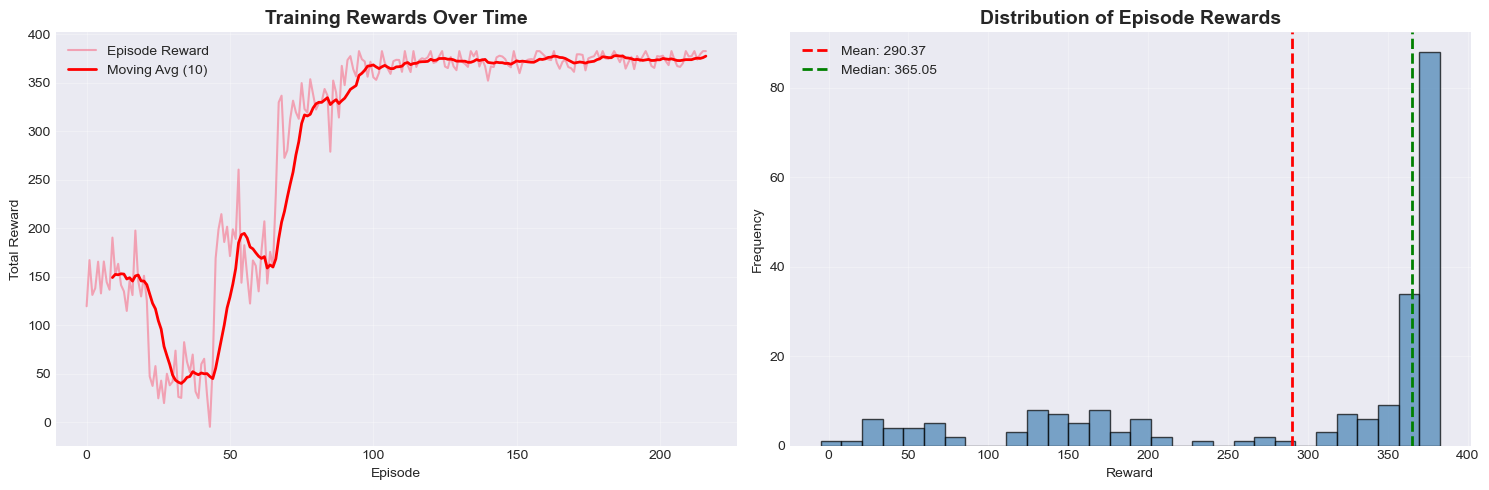


TRAINING STATISTICS
Total episodes: 217
Mean reward: 290.37
Std reward: 119.00
Min reward: -4.93
Max reward: 382.68

Last 10 episodes:
  Mean reward: 377.54
  Std reward: 5.47


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Episode rewards
ax = axes[0]
ax.plot(training_rewards, alpha=0.6, label='Episode Reward')
ax.plot(pd.Series(training_rewards).rolling(10).mean(), linewidth=2, label='Moving Avg (10)', color='red')
ax.set_title('Training Rewards Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.legend()
ax.grid(True, alpha=0.3)

# Distribution of rewards
ax = axes[1]
ax.hist(training_rewards, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=np.mean(training_rewards), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(training_rewards):.2f}')
ax.axvline(x=np.median(training_rewards), color='green', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(training_rewards):.2f}')
ax.set_title('Distribution of Episode Rewards', fontsize=14, fontweight='bold')
ax.set_xlabel('Reward')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TRAINING STATISTICS")
print("="*70)
print(f"Total episodes: {len(training_rewards)}")
print(f"Mean reward: {np.mean(training_rewards):.2f}")
print(f"Std reward: {np.std(training_rewards):.2f}")
print(f"Min reward: {np.min(training_rewards):.2f}")
print(f"Max reward: {np.max(training_rewards):.2f}")
print(f"\nLast 10 episodes:")
print(f"  Mean reward: {np.mean(training_rewards[-10:]):.2f}")
print(f"  Std reward: {np.std(training_rewards[-10:]):.2f}")
print("="*70)

## 6. Evaluate Trained Agent

Test the trained agent and analyze its allocation decisions.

In [44]:
# Evaluate trained agent
def evaluate_agent(agent, env, num_episodes=10, max_steps=200):
    """
    Evaluate trained agent performance.
    """
    
    all_rewards = []
    all_returns = []
    all_sharpes = []
    all_allocations = []
    all_portfolio_values = []
    
    print(f"Evaluating agent over {num_episodes} episodes...\n")
    
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        initial_value = info['portfolio_value']
        episode_allocations = []
        episode_pf_values = [initial_value]
        
        for step in range(max_steps):
            # Get action (deterministic) - select_action returns (action, log_prob, value)
            action, _, _ = agent.select_action(state, deterministic=True)
            
            next_state, reward, terminated, truncated, info = env.step(action)
            
            episode_reward += reward
            episode_allocations.append(info['weights'].copy())
            episode_pf_values.append(info['portfolio_value'])
            
            state = next_state
            
            if terminated or truncated:
                break
        
        final_value = info['portfolio_value']
        episode_return = (final_value / initial_value - 1) * 100
        episode_sharpe = info.get('sharpe_ratio', 0)
        
        all_rewards.append(episode_reward)
        all_returns.append(episode_return)
        all_sharpes.append(episode_sharpe)
        all_allocations.append(episode_allocations)
        all_portfolio_values.append(episode_pf_values)
        
        print(f"Episode {episode+1}: Reward={episode_reward:7.2f}, Return={episode_return:6.2f}%, Sharpe={episode_sharpe:5.2f}")
    
    print(f"\n✓ Evaluation complete!")
    print(f"  Mean reward: {np.mean(all_rewards):.2f} ± {np.std(all_rewards):.2f}")
    print(f"  Mean return: {np.mean(all_returns):.2f}% ± {np.std(all_returns):.2f}%")
    print(f"  Mean Sharpe: {np.mean(all_sharpes):.2f} ± {np.std(all_sharpes):.2f}")
    
    return all_rewards, all_returns, all_sharpes, all_allocations, all_portfolio_values

# Run evaluation
eval_rewards, eval_returns, eval_sharpes, eval_allocations, eval_pf_values = evaluate_agent(
    agent=agent,
    env=env,
    num_episodes=10,
    max_steps=200
)

Evaluating agent over 10 episodes...

Episode 1: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 1: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 2: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 2: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 3: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 3: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 4: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 4: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 5: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 5: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 6: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 6: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 7: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 7: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 8: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 8: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 9: Reward= 382.68, Return=101.81%, Sharpe=42.49
Episode 9:

## 7. Analyze Allocation Strategy

Visualize how the agent allocates capital across strategies over time.

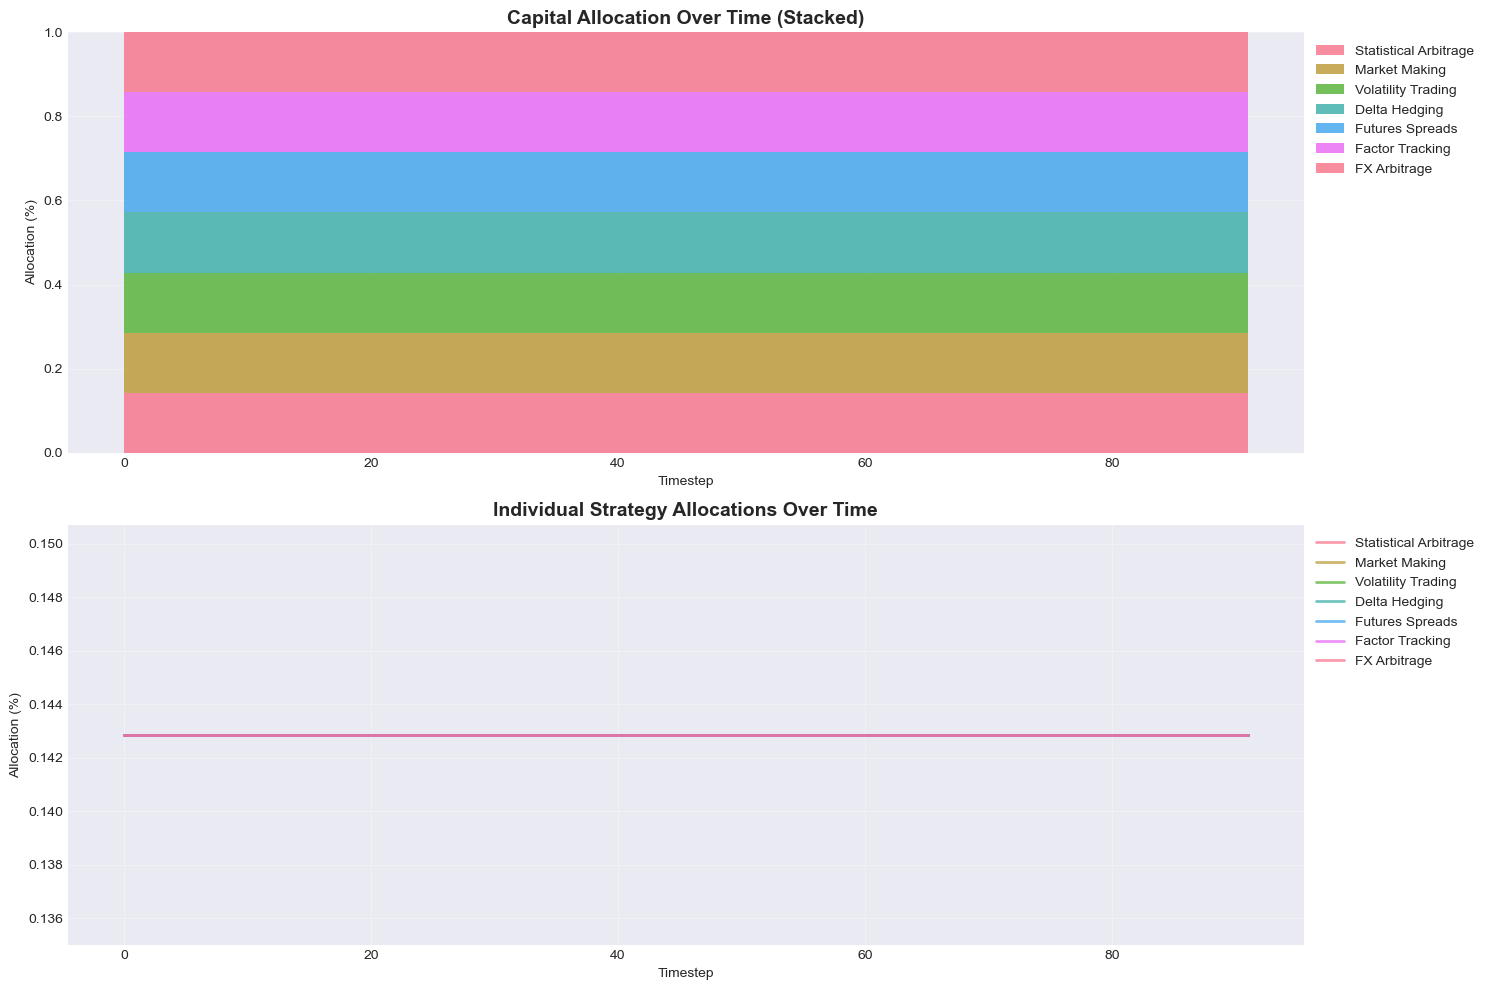


AVERAGE ALLOCATION ACROSS STRATEGIES
Statistical Arbitrage: 14.29%
Market Making       : 14.29%
Volatility Trading  : 14.29%
Delta Hedging       : 14.29%
Futures Spreads     : 14.29%
Factor Tracking     : 14.29%
FX Arbitrage        : 14.29%
Total               : 100.00%


In [45]:
# Analyze allocation patterns from first evaluation episode
allocations = np.array(eval_allocations[0])  # Take first episode

strategy_names = ['Statistical Arbitrage', 'Market Making', 'Volatility Trading', 'Delta Hedging', 
                  'Futures Spreads', 'Factor Tracking', 'FX Arbitrage']

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Stacked area chart of allocations over time
ax = axes[0]
ax.stackplot(range(len(allocations)), allocations.T, labels=strategy_names, alpha=0.8)
ax.set_title('Capital Allocation Over Time (Stacked)', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Allocation (%)')
ax.set_ylim(0, 1)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

# Individual allocation lines
ax = axes[1]
for i, name in enumerate(strategy_names):
    ax.plot(allocations[:, i], label=name, linewidth=2, alpha=0.7)
ax.set_title('Individual Strategy Allocations Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Allocation (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate average allocations
avg_allocations = np.mean(allocations, axis=0)

print("\n" + "="*70)
print("AVERAGE ALLOCATION ACROSS STRATEGIES")
print("="*70)
for i, name in enumerate(strategy_names):
    print(f"{name:20s}: {avg_allocations[i]:6.2%}")
print("="*70)
print(f"{'Total':20s}: {avg_allocations.sum():6.2%}")
print("="*70)

## 8. Compare with Baseline Strategies

Compare the trained agent against simple baseline allocation strategies:
- **Equal Weight**: 1/7 allocation to each strategy
- **Risk Parity**: Allocate inversely proportional to volatility
- **Sharpe-Weighted**: Allocate proportional to historical Sharpe ratios

In [46]:
def test_baseline_strategy(env, strategy_type='equal_weight', num_episodes=10):
    """
    Test baseline allocation strategies.
    
    Args:
        env: CIO allocator environment
        strategy_type: 'equal_weight', 'risk_parity', or 'sharpe_weighted'
        num_episodes: Number of test episodes
    """
    
    all_rewards = []
    all_returns = []
    all_sharpes = []
    
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        initial_value = info['portfolio_value']
        
        for step in range(200):
            # Determine baseline action based on strategy
            if strategy_type == 'equal_weight':
                # Equal allocation to all strategies
                action = np.ones(7) / 7
                
            elif strategy_type == 'risk_parity':
                # Allocate inversely proportional to volatility
                # Get volatility from specialist data
                vols = []
                for strat in strategies:
                    vol = specialist_data.iloc[env.current_step].get(f'{strat}_vol', 0.10)
                    vols.append(vol)
                inv_vols = 1.0 / (np.array(vols) + 1e-6)
                action = inv_vols / inv_vols.sum()
                
            elif strategy_type == 'sharpe_weighted':
                # Allocate proportional to Sharpe ratios (positive only)
                sharpes = []
                for strat in strategies:
                    sharpe = specialist_data.iloc[env.current_step].get(f'{strat}_sharpe', 0)
                    sharpes.append(max(sharpe, 0))  # Only positive Sharpes
                sharpes = np.array(sharpes)
                if sharpes.sum() > 0:
                    action = sharpes / sharpes.sum()
                else:
                    action = np.ones(7) / 7
            
            next_state, reward, terminated, truncated, info = env.step(action)
            
            episode_reward += reward
            state = next_state
            
            if terminated or truncated:
                break
        
        final_value = info['portfolio_value']
        episode_return = (final_value / initial_value - 1) * 100
        episode_sharpe = info.get('sharpe_ratio', 0)
        
        all_rewards.append(episode_reward)
        all_returns.append(episode_return)
        all_sharpes.append(episode_sharpe)
    
    return np.mean(all_rewards), np.mean(all_returns), np.mean(all_sharpes)

# Test baselines
print("Testing baseline strategies...\n")

baseline_results = {}

for strategy_name in ['equal_weight', 'risk_parity', 'sharpe_weighted']:
    avg_reward, avg_return, avg_sharpe = test_baseline_strategy(env, strategy_name, num_episodes=10)
    baseline_results[strategy_name] = {
        'reward': avg_reward,
        'return': avg_return,
        'sharpe': avg_sharpe
    }
    print(f"{strategy_name.replace('_', ' ').title():20s}: Reward={avg_reward:7.2f}, Return={avg_return:6.2f}%, Sharpe={avg_sharpe:5.2f}")

# Add trained agent results
baseline_results['trained_agent'] = {
    'reward': np.mean(eval_rewards),
    'return': np.mean(eval_returns),
    'sharpe': np.mean(eval_sharpes)
}
print(f"{'Trained Agent (PPO)':20s}: Reward={np.mean(eval_rewards):7.2f}, Return={np.mean(eval_returns):6.2f}%, Sharpe={np.mean(eval_sharpes):5.2f}")

print("\n✓ Baseline comparison complete!")

Testing baseline strategies...

Equal Weight        : Reward= 382.68, Return=101.81%, Sharpe=42.49
Equal Weight        : Reward= 382.68, Return=101.81%, Sharpe=42.49
Risk Parity         : Reward= 407.28, Return=102.04%, Sharpe=46.25
Risk Parity         : Reward= 407.28, Return=102.04%, Sharpe=46.25
Sharpe Weighted     : Reward= 413.96, Return=113.69%, Sharpe=47.16
Trained Agent (PPO) : Reward= 382.68, Return=101.81%, Sharpe=42.49

✓ Baseline comparison complete!
Sharpe Weighted     : Reward= 413.96, Return=113.69%, Sharpe=47.16
Trained Agent (PPO) : Reward= 382.68, Return=101.81%, Sharpe=42.49

✓ Baseline comparison complete!


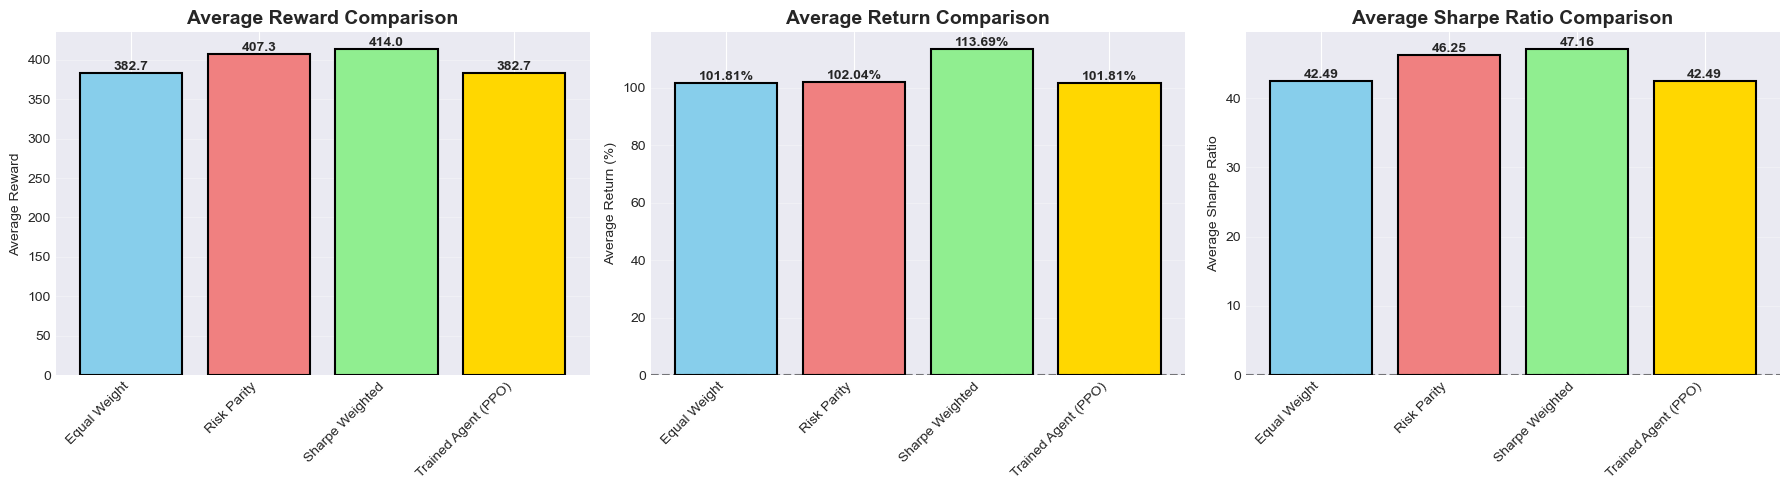


PERFORMANCE COMPARISON SUMMARY
Strategy                    Avg Reward   Avg Return   Avg Sharpe
--------------------------------------------------------------------------------
Equal Weight                    382.68      101.81%        42.49
Risk Parity                     407.28      102.04%        46.25
Sharpe Weighted                 413.96      113.69%        47.16
Trained Agent (PPO)             382.68      101.81%        42.49


In [47]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies_list = ['equal_weight', 'risk_parity', 'sharpe_weighted', 'trained_agent']
strategy_labels = ['Equal Weight', 'Risk Parity', 'Sharpe Weighted', 'Trained Agent (PPO)']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

# Rewards comparison
ax = axes[0]
rewards = [baseline_results[s]['reward'] for s in strategies_list]
bars = ax.bar(strategy_labels, rewards, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Average Reward Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Reward')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Returns comparison
ax = axes[1]
returns = [baseline_results[s]['return'] for s in strategies_list]
bars = ax.bar(strategy_labels, returns, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Average Return Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Return (%)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

# Sharpe comparison
ax = axes[2]
sharpes = [baseline_results[s]['sharpe'] for s in strategies_list]
bars = ax.bar(strategy_labels, sharpes, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Average Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Sharpe Ratio')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

# Performance summary table
print("\n" + "="*80)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*80)
print(f"{'Strategy':<25} {'Avg Reward':>12} {'Avg Return':>12} {'Avg Sharpe':>12}")
print("-"*80)
for strat, label in zip(strategies_list, strategy_labels):
    r = baseline_results[strat]
    print(f"{label:<25} {r['reward']:>12.2f} {r['return']:>11.2f}% {r['sharpe']:>12.2f}")
print("="*80)

## 9. Save Trained Model

Save the trained PPO agent for future use.

In [48]:
# Create models directory
models_dir = Path.cwd().parent / 'models' / 'master'
models_dir.mkdir(parents=True, exist_ok=True)

# Save agent
model_path = models_dir / 'ppo_cio_allocator.pt'
agent.save(str(model_path))

print(f"✓ Model saved to: {model_path}")
print(f"  File size: {model_path.stat().st_size / 1024:.2f} KB")

# Save training and evaluation metrics
metrics_path = models_dir / 'training_metrics.npz'
np.savez(
    metrics_path,
    training_rewards=training_rewards,
    eval_rewards=eval_rewards,
    eval_returns=eval_returns,
    eval_sharpes=eval_sharpes
)

print(f"✓ Training metrics saved to: {metrics_path}")

# Save configuration
config_path = models_dir / 'config.txt'
with open(config_path, 'w') as f:
    f.write("CIO ALLOCATOR TRAINING CONFIGURATION\n")
    f.write("="*70 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write("Environment Settings:\n")
    f.write(f"  Initial Capital: ${env.initial_capital:,.0f}\n")
    f.write(f"  Number of Strategies: {len(env.STRATEGIES)}\n")
    f.write(f"  Lookback Window: {env.lookback_window}\n")
    f.write(f"  Rebalance Frequency: {env.rebalance_frequency}\n")
    f.write(f"  Transaction Cost: {env.transaction_cost:.4f}\n\n")
    f.write("Agent Settings:\n")
    f.write(f"  Algorithm: PPO\n")
    f.write(f"  Learning Rate: 3e-4\n")
    f.write(f"  Hidden Dimensions: (256, 256)\n")
    f.write(f"  Gamma: 0.99\n")
    f.write(f"  GAE Lambda: 0.95\n")
    f.write(f"  Clip Epsilon: 0.2\n")
    f.write(f"  N Steps: 2048\n")
    f.write(f"  Batch Size: 64\n")
    f.write(f"  N Epochs: 10\n\n")
    f.write("Training Results:\n")
    f.write(f"  Total Episodes: {len(training_rewards)}\n")
    f.write(f"  Mean Reward: {np.mean(training_rewards):.2f}\n")
    f.write(f"  Final Avg Reward (last 10): {np.mean(training_rewards[-10:]):.2f}\n\n")
    f.write("Evaluation Results:\n")
    f.write(f"  Episodes: {len(eval_rewards)}\n")
    f.write(f"  Mean Reward: {np.mean(eval_rewards):.2f}\n")
    f.write(f"  Mean Return: {np.mean(eval_returns):.2f}%\n")
    f.write(f"  Mean Sharpe: {np.mean(eval_sharpes):.2f}\n")

print(f"✓ Configuration saved to: {config_path}")

print(f"\n{'='*70}")
print("MODEL SAVED SUCCESSFULLY!")
print(f"{'='*70}")

Model saved to c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\master\ppo_cio_allocator.pt
✓ Model saved to: c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\master\ppo_cio_allocator.pt
  File size: 1339.48 KB
✓ Training metrics saved to: c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\master\training_metrics.npz
✓ Configuration saved to: c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\master\config.txt

MODEL SAVED SUCCESSFULLY!
